
# 四川成渝 (601717.SH) Beta、HAC & 因果性检验

参考仓库缓存的 Tushare 文档：
- 股票日线：`tushare_api_docs/股票数据/行情数据/历史日线_docid27.txt`
- 指数日线：`tushare_api_docs/指数专题/指数日线行情_docid95.txt`

在 Whitelist 网络环境下，直接使用 Pro 接口数据，检验四川成渝相对沪深300指数的 Beta，并引入动量控制、HAC 稳健标准误以及 Granger 因果检验。


## 分析流程
1. 读取 Token，初始化 `ts.pro_api`（参见 `README.md` / `TUSHARE_CONFIG.md`）。
2. 设定近 3 年为主窗口，同时输出近 120 交易日的敏感度版本。
3. 通过 Pro 接口调用 `daily`、`index_daily`，如遇空数据直接报错（不再使用旧式 `get_k_data`）。
4. 对齐交易日，计算日收益与 60 日动量。
5. 运行协方差 Beta、CAPM（单因素）、含动量的多因素 OLS，并采用 HAC（Newey-West）稳健标准误。
6. 对残差执行 Jarque-Bera、White、Breusch-Pagan 检验。
7. 对两个时间窗口分别执行 Granger 因果检验。
8. 绘制价格走势、收益相关散点与残差诊断。

In [1]:
import os
from pathlib import Path
import datetime as dt
from typing import Optional
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tushare as ts
from IPython.display import display
from statsmodels.api import OLS, add_constant
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.tsa.stattools import grangercausalitytests

warnings.filterwarnings("ignore", message="verbose is deprecated", category=FutureWarning)
plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_context("talk")

from matplotlib import font_manager
font_paths = [
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc',
]
for font_path in font_paths:
    if os.path.exists(font_path):
        try:
            font_manager.fontManager.addfont(font_path)
        except Exception:
            pass
try:
    font_manager._rebuild()
except AttributeError:
    pass
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
preferred_fonts = [
    'Noto Sans CJK SC',
    'Noto Sans CJK JP',
    'SimHei',
    'Microsoft YaHei',
    'WenQuanYi Micro Hei',
    'Source Han Sans SC',
    'Droid Sans Fallback',
]
selected_font = None
for font in preferred_fonts:
    if font in available_fonts:
        selected_font = font
        break
plt.rcParams['font.family'] = 'sans-serif'
if selected_font:
    plt.rcParams['font.sans-serif'] = [selected_font, 'DejaVu Sans']
    print(f"Using font: {selected_font}")
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    print('Using default DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False


Using font: Noto Sans CJK JP


## Token 与客户端初始化

In [2]:

def load_token() -> Optional[str]:
    env_token = os.getenv('TUSHARE_API_KEY')
    if env_token:
        return env_token.strip()
    for candidate in [Path('.tushare_token'), Path.home() / '.tushare_token']:
        if candidate.is_file():
            token = candidate.read_text(encoding='utf-8').strip()
            if token:
                return token
    return None


def init_pro_client(base_url: Optional[str] = None):
    token = load_token()
    if not token:
        raise RuntimeError('未能读取 Tushare Token：请先配置 TUSHARE_API_KEY 或 .tushare_token')
    pro_client = ts.pro_api(token)
    if base_url:
        pro_client._DataApi__http_url = base_url.rstrip('/')
    return pro_client

BASE_URL = os.getenv('TUSHARE_BASE_URL') or 'http://api.tushare.pro/dataapi'
pro = init_pro_client(BASE_URL)
print(f"Base URL = {getattr(pro, '_DataApi__http_url', 'default')}")


Base URL = http://api.tushare.pro/dataapi


## 参数设定

In [3]:

ASSET_CODE = '601717.SH'
MARKET_CODE = '000300.SH'
YEARS_LOOKBACK = 3
MOMENTUM_WINDOW = 60  # 日收益动量
SHORT_WINDOW_DAYS = 120  # 近 120 个交易日
HAC_LAGS = 5  # Newey-West 最大滞后
GRANGER_MAX_LAG = 5

end_date = dt.date.today()
start_date = end_date - dt.timedelta(days=YEARS_LOOKBACK * 365)
START_DATE = start_date.strftime('%Y%m%d')
END_DATE = end_date.strftime('%Y%m%d')

print(
    f"分析区间: {START_DATE} ~ {END_DATE}\n"
    f"股票: {ASSET_CODE} | 指数: {MARKET_CODE}\n"
    f"动量窗口: {MOMENTUM_WINDOW} 日 | HAC lag={HAC_LAGS} | 短窗口={SHORT_WINDOW_DAYS} 交易日"
)


分析区间: 20221211 ~ 20251210
股票: 601717.SH | 指数: 000300.SH
动量窗口: 60 日 | HAC lag=5 | 短窗口=120 交易日


## 拉取 Pro 行情数据

In [4]:

def fetch_pro_daily(ts_code: str, is_index: bool = False) -> pd.DataFrame:
    fields = 'trade_date,open,high,low,close,vol'
    fetcher = pro.index_daily if is_index else pro.daily
    df = fetcher(ts_code=ts_code, start_date=START_DATE, end_date=END_DATE, fields=fields)
    if df.empty:
        raise RuntimeError(f'Pro 数据为空：{ts_code}，请检查权限或网络。')
    df['trade_date'] = pd.to_datetime(df['trade_date'])
    df.sort_values('trade_date', inplace=True)
    return df


stock_raw = fetch_pro_daily(ASSET_CODE, is_index=False)
index_raw = fetch_pro_daily(MARKET_CODE, is_index=True)
print(f"股票样本: {len(stock_raw)} 行 | 指数样本: {len(index_raw)} 行")
stock_raw.head()


股票样本: 726 行 | 指数样本: 726 行


,trade_date,open,high,low,close,vol
725,2022-12-12,12.3900,12.5000,11.9300,12.1500,"213,975.6100"
724,2022-12-13,12.1500,12.2000,11.9800,12.0700,"111,004.5400"
723,2022-12-14,12.0400,12.1900,11.9100,11.9700,"89,794.1300"
722,2022-12-15,11.9300,12.0300,11.7500,12.0300,"134,780.2500"
721,2022-12-16,11.9400,11.9800,11.5200,11.8000,"166,657.5900"


## 对齐交易日 & 构造收益/动量

In [5]:

def prepare_returns(df: pd.DataFrame, label: str) -> pd.DataFrame:
    frame = df[['trade_date', 'close']].copy()
    frame.rename(columns={'close': f'close_{label}'}, inplace=True)
    frame[f'ret_{label}'] = frame[f'close_{label}'].pct_change()
    return frame

stock = prepare_returns(stock_raw, 'stock')
index_df = prepare_returns(index_raw, 'index')
combined = pd.merge(stock, index_df, on='trade_date', how='inner')
combined['mom_stock'] = combined['close_stock'].pct_change(MOMENTUM_WINDOW)
combined['mom_index'] = combined['close_index'].pct_change(MOMENTUM_WINDOW)
combined.dropna(inplace=True)
combined.reset_index(drop=True, inplace=True)
print(f"对齐后样本量: {len(combined)} 个交易日")
combined.tail()


对齐后样本量: 666 个交易日


,trade_date,close_stock,ret_stock,close_index,ret_index,mom_stock,mom_index
661,2025-12-03,23.9200,0.0187,"4,531.0486",-0.0051,0.1214,0.0090
662,2025-12-04,24.2400,0.0134,"4,546.5664",0.0034,0.1253,0.0194
663,2025-12-05,24.6200,0.0157,"4,584.5368",0.0084,0.1797,0.0502
664,2025-12-08,24.3200,-0.0122,"4,621.7545",0.0081,0.1317,0.0362
665,2025-12-09,24.1500,-0.0070,"4,598.2232",-0.0051,0.1053,0.0292


## 划分分析窗口

In [6]:

def slice_recent(df: pd.DataFrame, trading_days: int) -> pd.DataFrame:
    if trading_days >= len(df):
        return df.copy()
    return df.tail(trading_days).copy()

window_3y = combined.copy()
window_120 = slice_recent(combined, SHORT_WINDOW_DAYS)
print(f"近3年样本: {len(window_3y)} | 近{SHORT_WINDOW_DAYS}日样本: {len(window_120)}")


近3年样本: 666 | 近120日样本: 120


## 回归与检验函数（含 HAC）

In [7]:

def run_analysis(window_df: pd.DataFrame, label: str):
    print(f"\n=== {label} ===")
    print(f"样本量: {len(window_df)}")
    desc = window_df[['ret_stock', 'ret_index', 'mom_stock', 'mom_index']].describe().T
    display(desc)

    beta_cov = window_df['ret_stock'].cov(window_df['ret_index']) / window_df['ret_index'].var()
    alpha_cov = window_df['ret_stock'].mean() - beta_cov * window_df['ret_index'].mean()
    print(f"协方差 Beta = {beta_cov:.4f} | Alpha = {alpha_cov:.6f}")

    X_capm = add_constant(window_df['ret_index'])
    capm = OLS(window_df['ret_stock'], X_capm).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS})
    print("\nCAPM (HAC) 回归结果：")
    print(capm.summary())

    X_multi = add_constant(window_df[['ret_index', 'mom_stock', 'mom_index']])
    multi = OLS(window_df['ret_stock'], X_multi).fit(cov_type='HAC', cov_kwds={'maxlags': HAC_LAGS})
    print("\n多因素 (HAC) 回归结果：")
    print(multi.summary())

    residuals = multi.resid
    jb_stat, jb_p, skew, kurtosis = jarque_bera(residuals)
    white_stat, white_p, white_f, white_fp = het_white(residuals, X_multi)
    bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, X_multi)

    diag = pd.DataFrame(
        {
            'statistic': [jb_stat, white_stat, bp_stat],
            'p_value': [jb_p, white_p, bp_p],
            'extra': [
                f'skew={skew:.3f}, kurtosis={kurtosis:.3f}',
                f'f_stat={white_f:.3f}, f_p={white_fp:.3f}',
                f'f_stat={bp_f:.3f}, f_p={bp_fp:.3f}'
            ],
        },
        index=['Jarque-Bera', 'White', 'Breusch-Pagan']
    )
    print("\n残差检验：")
    display(diag)

    lag = min(GRANGER_MAX_LAG, max(1, len(window_df)//20))
    g1 = grangercausalitytests(window_df[['ret_stock', 'ret_index']], maxlag=lag, verbose=False)
    g2 = grangercausalitytests(window_df[['ret_index', 'ret_stock']], maxlag=lag, verbose=False)

    def extract_pvals(result_dict):
        records = []
        for k, res in result_dict.items():
            p_val = res[0]['ssr_chi2test'][1]
            records.append({'lag': k, 'p_value': p_val})
        return pd.DataFrame(records).set_index('lag')

    print(f"\nGranger: 指数→个股 (max lag={lag})")
    display(extract_pvals(g1))
    print("Granger: 个股→指数")
    display(extract_pvals(g2))

    return {
        'desc': desc,
        'capm': capm,
        'multi': multi,
        'diag': diag,
    }


## 近 3 年窗口结果

In [8]:
results_3y = run_analysis(window_3y, "近3年")


=== 近3年 ===
样本量: 666


,count,mean,std,min,25%,50%,75%,max
ret_stock,666.0000,0.0011,0.0206,-0.0916,-0.0105,0.0000,0.0101,0.1001
ret_index,666.0000,0.0003,0.0109,-0.0705,-0.0054,-0.0002,0.0052,0.0848
mom_stock,666.0000,0.0727,0.1734,-0.3498,-0.0327,0.0885,0.1796,0.6631
mom_index,666.0000,0.0152,0.0863,-0.1199,-0.0472,-0.0086,0.0691,0.2606


协方差 Beta = 0.9676 | Alpha = 0.000809

CAPM (HAC) 回归结果：
                            OLS Regression Results                            
Dep. Variable:              ret_stock   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     229.0
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           1.17e-44
Time:                        14:14:58   Log-Likelihood:                 1741.9
No. Observations:                 666   AIC:                            -3480.
Df Residuals:                     664   BIC:                            -3471.
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

,statistic,p_value,extra
Jarque-Bera,619.9701,0.0000,"skew=0.523, kurtosis=7.609"
White,37.8735,0.0000,"f_stat=4.395, f_p=0.000"
Breusch-Pagan,16.4848,0.0009,"f_stat=5.601, f_p=0.001"



Granger: 指数→个股 (max lag=5)


,p_value
lag,
1,0.6541
2,0.5128
3,0.1993
4,0.1994
5,0.1895


Granger: 个股→指数


,p_value
lag,
1,0.0578
2,0.0615
3,0.0420
4,0.0283
5,0.0147


## 近 120 交易日窗口结果

In [9]:
results_120 = run_analysis(window_120, "近120交易日")


=== 近120交易日 ===
样本量: 120


,count,mean,std,min,25%,50%,75%,max
ret_stock,120.0000,0.0030,0.0241,-0.0686,-0.0115,0.0000,0.0136,0.1001
ret_index,120.0000,0.0015,0.0091,-0.0244,-0.0044,0.0021,0.0068,0.0231
mom_stock,120.0000,0.2447,0.1414,0.0486,0.1218,0.2045,0.3511,0.6631
mom_index,120.0000,0.0932,0.0564,-0.0343,0.0555,0.0956,0.1436,0.1834


协方差 Beta = 0.9873 | Alpha = 0.001562

CAPM (HAC) 回归结果：
                            OLS Regression Results                            
Dep. Variable:              ret_stock   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     28.78
Date:                Wed, 10 Dec 2025   Prob (F-statistic):           4.10e-07
Time:                        14:14:58   Log-Likelihood:                 286.08
No. Observations:                 120   AIC:                            -568.2
Df Residuals:                     118   BIC:                            -562.6
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

,statistic,p_value,extra
Jarque-Bera,104.5554,0.0000,"skew=0.870, kurtosis=7.229"
White,27.5173,0.0011,"f_stat=3.637, f_p=0.001"
Breusch-Pagan,9.2580,0.0261,"f_stat=3.233, f_p=0.025"



Granger: 指数→个股 (max lag=5)


,p_value
lag,
1,0.6733
2,0.9240
3,0.0752
4,0.0538
5,0.0933


Granger: 个股→指数


,p_value
lag,
1,0.4468
2,0.6199
3,0.6268
4,0.6738
5,0.2730


## 可视化：价格与收益

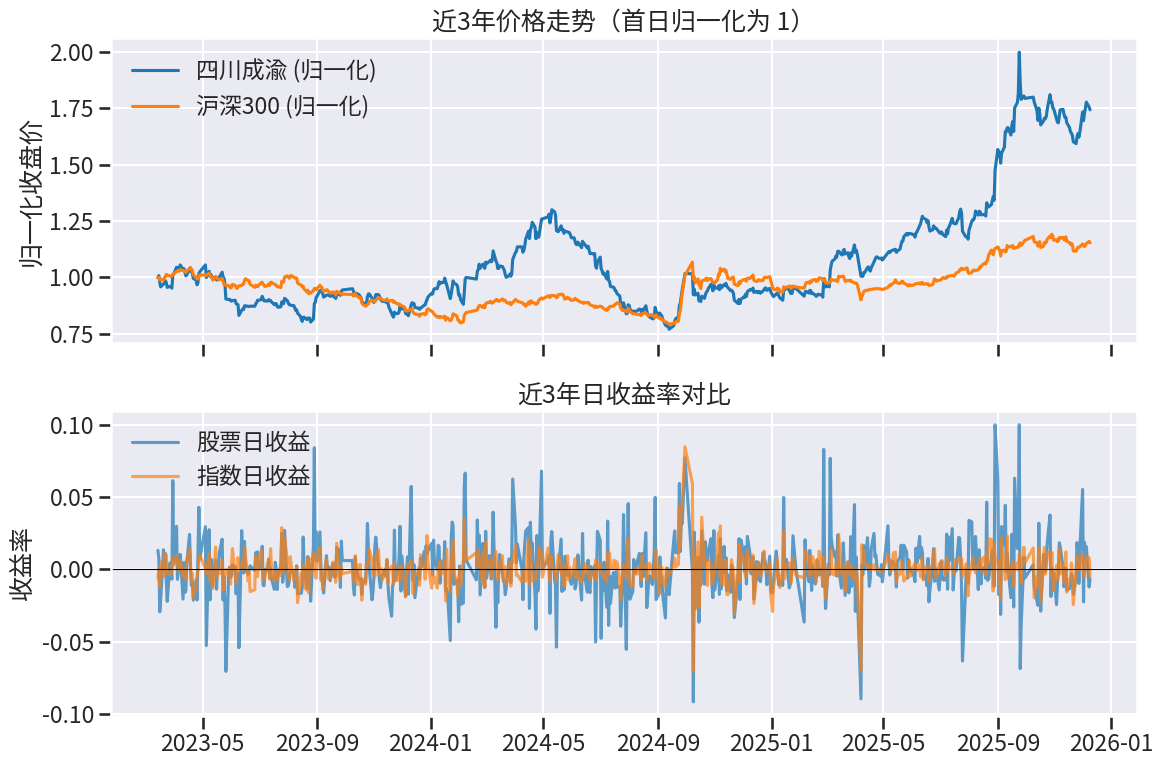

In [10]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

panel = window_3y[['trade_date', 'close_stock', 'close_index']].set_index('trade_date')
normed = panel / panel.iloc[0]
axes[0].plot(normed.index, normed['close_stock'], label='四川成渝 (归一化)')
axes[0].plot(normed.index, normed['close_index'], label='沪深300 (归一化)')
axes[0].set_title('近3年价格走势（首日归一化为 1）')
axes[0].set_ylabel('归一化收盘价')
axes[0].legend()

axes[1].plot(window_3y['trade_date'], window_3y['ret_stock'], label='股票日收益', alpha=0.7)
axes[1].plot(window_3y['trade_date'], window_3y['ret_index'], label='指数日收益', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('近3年日收益率对比')
axes[1].set_ylabel('收益率')
axes[1].legend()

plt.tight_layout()
plt.show()


## 可视化：收益散点与残差

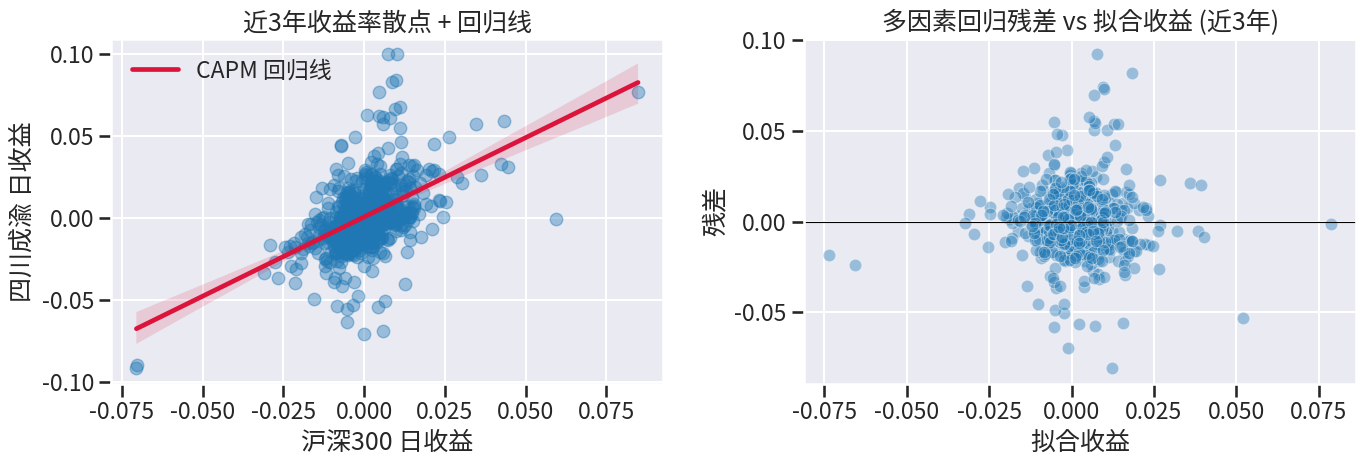

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x='ret_index', y='ret_stock', data=window_3y, ax=axes[0],
            line_kws={'color': 'crimson', 'label': 'CAPM 回归线'},
            scatter_kws={'alpha': 0.4})
axes[0].set_title('近3年收益率散点 + 回归线')
axes[0].set_xlabel('沪深300 日收益')
axes[0].set_ylabel('四川成渝 日收益')
axes[0].legend()

sns.scatterplot(x=results_3y['multi'].fittedvalues, y=results_3y['multi'].resid, ax=axes[1], alpha=0.4)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('多因素回归残差 vs 拟合收益 (近3年)')
axes[1].set_xlabel('拟合收益')
axes[1].set_ylabel('残差')

plt.tight_layout()
plt.show()



## 结论提示
- 通过 HAC (Newey-West) 处理后，CAPM 与多因素 Beta 的标准误更稳健，可直接关注 `ret_index` 的系数与 p 值；若 120 日窗口与 3 年窗口差异显著，说明 Beta 存在时变性。
- 若动量系数显著，说明除了市场因子外，股票自身或指数动量能解释额外收益，预测性分析需纳入这些变量。
- Granger 检验若在 1~5 日滞后拒绝“指数不导致个股”，说明指数对个股存在领先效应；若反向不显著，则 Beta 更偏市场解释角色。
- 残差检验若仍提示非正态/异方差，可进一步使用稳健协方差 (`cov_type='HAC'`) 以外的方案或切换至 GARCH、VAR、滚动回归等模型。
